# Information Data Science - Pizza Data Analysis
## (Project by Andrew Hsieh)

# Code Summary:
1. **Importing Python Libraries/Statements**
2. **Reading Pizza Dataset**
3. **Analyze the Original Dataset:**
 - Identify basics of dataset including columns, size, and datatype
4. **Cleaning the Original Dataset:**
 - Check for null values and duplicated rows
 - Check for outliers
 - Conversion of time format into a usable format
5. **Data Visualization**
 - Using Bar Chart, Scatter Plot, Pi Chart, Line Chart, and Histogram
 - Uses visualization technique to find correlation between attributes
6. **Conclusion**

## 1. Importing Python Libraries/Statements

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Reading dataset

In [8]:
# Dataset link - https://www.kaggle.com/code/mdismielhossenabir/pizza-sales-dataset/input
df = pd.read_excel("pizza_sales.xlsx")

## 3. Analyze the Original Dataset

#### Type of dataset

In [9]:
type(df)

pandas.core.frame.DataFrame

#### Head of dataset

In [10]:
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,2015-01-01 00:00:00,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,2015-01-01 00:00:00,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,2015-01-01 00:00:00,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,2015-01-01 00:00:00,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,2015-01-01 00:00:00,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


####  Shape of dataset

In [11]:
df.shape

(48620, 12)

#### Name of columns

In [10]:
df.columns

Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name'],
      dtype='object')

#### Basic info

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  object 
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  object 
 5   order_time         48620 non-null  object 
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  object 
 9   pizza_category     48620 non-null  object 
 10  pizza_ingredients  48620 non-null  object 
 11  pizza_name         48620 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 4.5+ MB


## 4. Cleaning the Original Dataset

#### Checking for null values

In [15]:
df.isnull().sum()

pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64

#### Checking for duplicate rows

In [16]:
df.duplicated().sum()

0

#### Checking for outliers

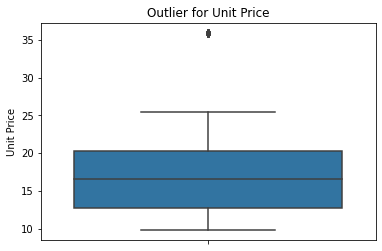

In [18]:
sns.boxplot(y=df['unit_price'])
plt.ylabel("Unit Price")
plt.title("Outlier for Unit Price")
plt.show()

There was an outlier when we did the boxplot based on the Unit Price column. However, after further examination, this outlier was NOT removed because most likely it was a real sale. It was more expensive due to the size and ingredients used. (The Greek Pizza, Size: XXL, Ingredients: Kalamata Olives, Feta Cheese, Tomatoes, Garlic, Beef Chuck Roast, Red Onions)

#### Converting time into usable format (Used in Analysis Q4)

In [ ]:
df['order_hour'] = pd.to_datetime(df['order_time'], format='%H:%M:%S').dt.hour

Converts the current format (hour:date:time, 11:38:36) to an integer of just the order_hour (11). The minutes and seconds are not necessary for future calculations.

The dataset was examined for null values, duplicates, inconsistent formatting, and outliers. After reviewing each column, the data had no null values and no duplicates. The outlier was kept as it was a real sale. Only the time was converted into a usable format for Analysis Q4. No further cleaning or transformation is necessary.

## 5. Data Visualization

#### Bar Chart Showing Top 5 Most Popular Pizzas

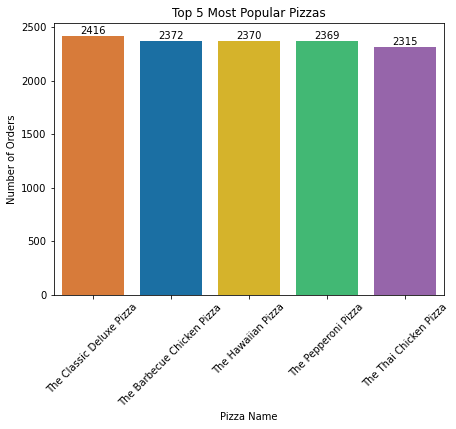

In [19]:
# Get top 5 pizzas
top_5_pizzas = df['pizza_name'].value_counts().head(5)

# Create bar plot
sns.barplot(x=top_5_pizzas.index, y=top_5_pizzas.values, 
            palette=["#F17720", '#0474ba', '#F1C40F', '#2ECC71', '#9B59B6'])
fig = plt.gcf()
fig.set_size_inches(7,5)
plt.title('Top 5 Most Popular Pizzas')
plt.xlabel('Pizza Name')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)

#Create numbers on the bar chart to show exact values of order
for i in range(len(top_5_pizzas)):
    plt.text(i, top_5_pizzas.values[i] + 20, str(top_5_pizzas.values[i]), ha='center')


Results:<br>
The top 5 most popular pizzas are in this order: Classic Deluxe Pizza, Barbecue Chicken Pizza, Hawaiian Pizza, Pepperoni Pizza, and Thai Chicken Pizza.
<br>Analysis:<br>
The range for number of orders from the 5 most popular pizzas are rather close. All 5 of them fall in the range of (2315 orders to 2416 orders) so about ~100 order difference. 


#### Pi Chart Showing The Size of Pizza Orders

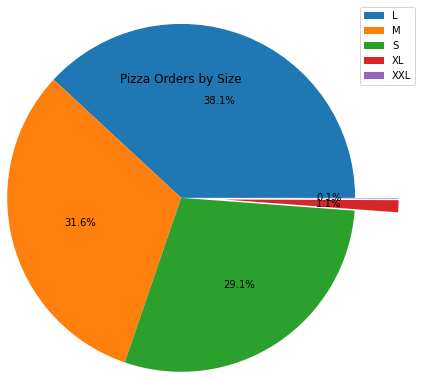

In [21]:
a = df.groupby(['pizza_size']).size().reset_index(name='counts')

#create pie chart
piechart = plt.pie(a['counts'],
                   radius=2.0,
                   autopct='%1.1f%%',
                   explode=[0.0, 0.0, 0.0, 0.5, 0.5])
plt.title("Pizza Orders by Size")
plt.legend(labels=a['pizza_size'], bbox_to_anchor=(1.3, 1.4))
plt.show()


Results:<br>
Large came in at 38.1%, Medium at 31.6%, Small at 29.1%, XL at 1.1%, and XXL at 0.1%.
<br>Analysis:<br>
The standard sizes of S, M, L dominated the pi chart. They were relatively equal all around at ~30%. The other sizes XL and XXL represented very little of the pi chart indicating that majority preferred the standard sizes.

#### Bar Chart Showing Average Revenue by Pizza Category

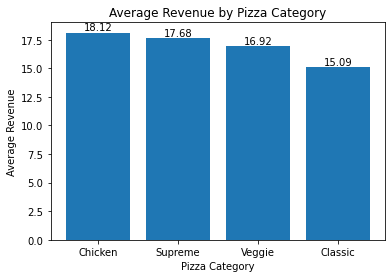

In [23]:
avg_revenue = df.groupby('pizza_category')['total_price'].mean().sort_values(ascending=False)

#create bar chart
plt.bar(avg_revenue.index, avg_revenue.values)
plt.xlabel('Pizza Category')
plt.ylabel('Average Revenue')
plt.title('Average Revenue by Pizza Category')

#Create numbers on the bar chart to show exact values of order
for i in range(len(avg_revenue)):
    plt.text(i, avg_revenue.values[i] * 1.01, f"{avg_revenue.values[i]:.2f}", ha='center')



Results:<br>
Chicken had the highest average revenue with 18.12, followed by Supreme with 17.68, followed by Veggie with 16.92, and finally Classic with 15.09.
<br>Analysis:<br>
This makes sense because on average meats are more expensive than vegetables so the graph should reflect this. The graph also shows that those with toppings are more expensive with those that do not have toppings.

#### Line Chart Showing Pizza Orders by Hour of Day

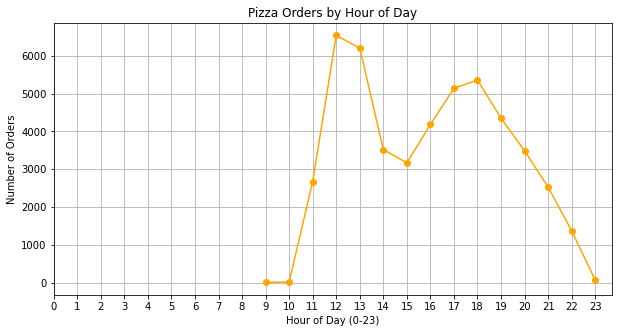

In [13]:
# Convert order_time to numeric hours (0-23)
df['order_hour'] = pd.to_datetime(df['order_time'], format='%H:%M:%S').dt.hour

# Count the number of orders for each hour
orders_by_hour = df['order_hour'].value_counts().sort_index()

# Plot the line chart
plt.figure(figsize=(10,5))
plt.plot(orders_by_hour.index, orders_by_hour.values, marker='o', color='orange')
plt.title('Pizza Orders by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Orders')
plt.xticks(range(0, 24))  
plt.grid(True)
plt.show()


Results:<br>
The number of orders started from hour 9 and increased till hour 12. Then there was a decrease from hour 13 to hour 15. From hour 15 to hour 18 it rose again. Then it decreased from hour 18 on to hour 23.
<br>Analysis:<br>
The dataset for this pizza business is shows that from hour 9 to hour 10 is most likely preparation time for the employees. The reason there are 2 peaks is because one is for lunch time and the other is for dinner time. This is when most people go out to eat.

#### Scatterplot Showing Relationship Between Pizza Size and Unit Price

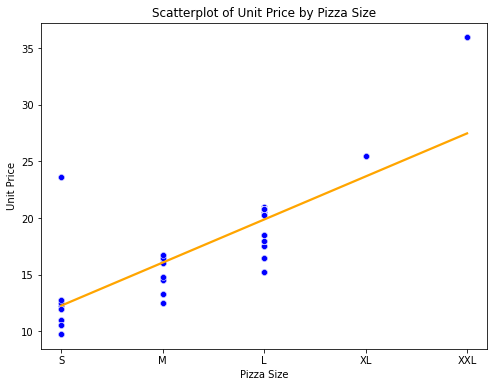

pizza_size
S      12.364328
M      15.951219
L      19.802553
XL     25.500000
XXL    35.950000
Name: unit_price, dtype: float64


In [14]:
# Ensure pizza_size is categorical in the desired order
size_order = ['S', 'M', 'L', 'XL', 'XXL']
df['pizza_size'] = pd.Categorical(df['pizza_size'], categories=size_order, ordered=True)

plt.figure(figsize=(8,6))

# Scatterplot with blue dots
sns.scatterplot(x='pizza_size', y='unit_price', data=df, color='blue')

# Line of best fit (orange)
sns.regplot(x=df['pizza_size'].cat.codes, y=df['unit_price'], 
            scatter=False, color='orange', ci=None)

# x-axis showing pizza sizes
plt.xticks(ticks=range(len(size_order)), labels=size_order)
plt.title('Scatterplot of Unit Price by Pizza Size')
plt.xlabel('Pizza Size')
plt.ylabel('Unit Price')
plt.show()
avg_price_by_size = df.groupby('pizza_size')['unit_price'].mean()
print(avg_price_by_size)


Results:<br>
The average cost of a small pizza is 12.36, medium is 15.95, large is 19.80, x-large is 25.50, and xx-large is 35.95.
<br>Analysis:<br>
The dataset shows that there is a correlation between pizza size and unit price. As the size of the pizza increases so does the average cost of the pizza. This makes sense as bigger pizzas use more dough and more ingredients/toppings so therefore it should be higher priced.

#### Histogram Showing Distribution of Total Order Amounts

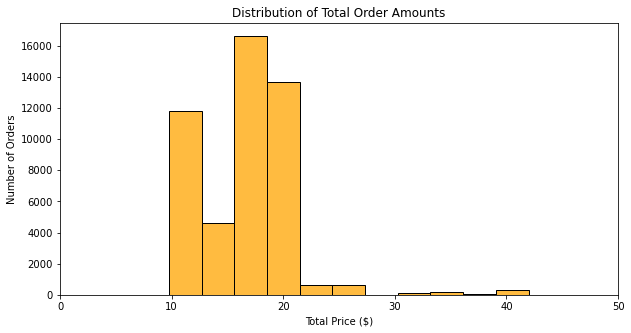

In [15]:
plt.figure(figsize=(10,5))
sns.histplot(df['total_price'], bins=25, color='orange')
plt.xlim(0, 50)  # Focus on the 0-50 range where most orders are
plt.title('Distribution of Total Order Amounts')
plt.xlabel('Total Price ($)')
plt.ylabel('Number of Orders')
plt.show()

Results:<br>
The number of orders was highest between 10 and 20. The number of orders above 20 were little compared to the ones between 10 and 20.
<br>Analysis:<br>
The dataset shows that most pizza orders ranged between 10 and 20 dollars. This shows that customers prefer usually one pizza at a standard size. Most pizzas between the sizes of small to large are between these two price points.  

## 6. Conclusion

From our analysis, we learned a lot about the customer base. There is no one single dominant pizza as the top 5 most popular pizzas are rather close in the amount of orders through the year. Most customers order pizza in the range of 10 to 20 dollars with a typical size of between small and large. Customers typically order the most at noon and the second most at dinner time. From this, a pizza business should be able to accurately prepare the amount of ingredients needed each day and should have an idea of how to maximize their business profit. An example could be promotions during the slower hours to increase business during those hours.